# Climate Anomalies, Disaster Frequency, and U.S. Equity Market Risk

**Student:** Zilun He

This project builds a simplified Climate Value at Risk investment workflow. The idea is inspired by Climate VaR frameworks: climate conditions create physical and transition risks, those risks can affect financial assets, and investors may respond by changing portfolio allocation.

The project does not estimate a full firm-level Climate VaR. Instead, it uses public data to build a climate-risk signal and tests a mock $50 million sector ETF portfolio from 2009 onward.

## Methodology

The simplified methodology is:

```text
climate input -> physical damage proxy -> climate-risk signal -> portfolio allocation -> backtest result
```

The climate-risk signal combines two public indicators:

1. NASA global temperature anomaly.
2. NOAA U.S. billion-dollar disaster frequency.

The climate-risk score is:

$$ClimateRisk_t = z(TemperatureAnomaly_t) + z(DisasterFrequency_t)$$

High-climate-risk years are years in the top quartile of this score. The mock portfolio uses the previous year's climate-risk state to set the next year's sector allocation.

## Data Sources

- NASA GISTEMP global temperature anomaly CSV: https://data.giss.nasa.gov/gistemp/data_v4.html
- NOAA Billion-Dollar Disaster state frequency CSV: https://www.ncei.noaa.gov/access/billions/mapping
- Market data from `yfinance`: XLE, XLU, XLI, XLK, XLF

All data are loaded directly in the notebook.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (11, 5)

## 1. Build the Climate-Risk Signal

NASA temperature anomalies measure the climate input. NOAA billion-dollar disaster counts proxy physical climate damage. Both variables are standardized and added together to form the climate-risk score.

In [20]:
temperature_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
disaster_url = "https://www.ncei.noaa.gov/access/billions/state-freq-data.csv"

temperature = pd.read_csv(temperature_url, skiprows=1, na_values="***")
temperature["J-D"] = pd.to_numeric(temperature["J-D"])
temperature = temperature[["Year", "J-D"]].rename(columns={"Year": "year", "J-D": "temperature_anomaly"})
temperature = temperature.set_index("year")

disasters = pd.read_csv(disaster_url, skiprows=1)
disaster_columns = disasters.columns[2:]
disaster_by_year = disasters.groupby("year")[disaster_columns].sum()
disaster_by_year["total_disasters"] = disaster_by_year.sum(axis=1)

climate = temperature.join(disaster_by_year["total_disasters"], how="inner")
climate = climate.loc[1980:2024]
climate["temperature_z"] = (climate["temperature_anomaly"] - climate["temperature_anomaly"].mean()) / climate["temperature_anomaly"].std()
climate["disaster_z"] = (climate["total_disasters"] - climate["total_disasters"].mean()) / climate["total_disasters"].std()
climate["climate_risk_score"] = climate["temperature_z"] + climate["disaster_z"]
risk_threshold = climate["climate_risk_score"].quantile(0.75)
climate["high_climate_risk"] = climate["climate_risk_score"] >= risk_threshold
climate.tail()

,temperature_anomaly,total_disasters,temperature_z,disaster_z,climate_risk_score,high_climate_risk
year,,,,,,
2020,1.01,208,1.539672,2.055947,3.595618,True
2021,0.85,187,0.983722,1.722178,2.705900,True
2022,0.89,180,1.122709,1.610921,2.733631,True
2023,1.17,242,2.095621,2.596335,4.691956,True
2024,1.28,271,2.477836,3.057254,5.535091,True


## Figure 1. Climate Data Overview

This figure gives more climate-data context: global temperature anomaly, total U.S. billion-dollar disaster frequency, disaster category breakdown, and a five-year average of the two standardized climate inputs used in the score.

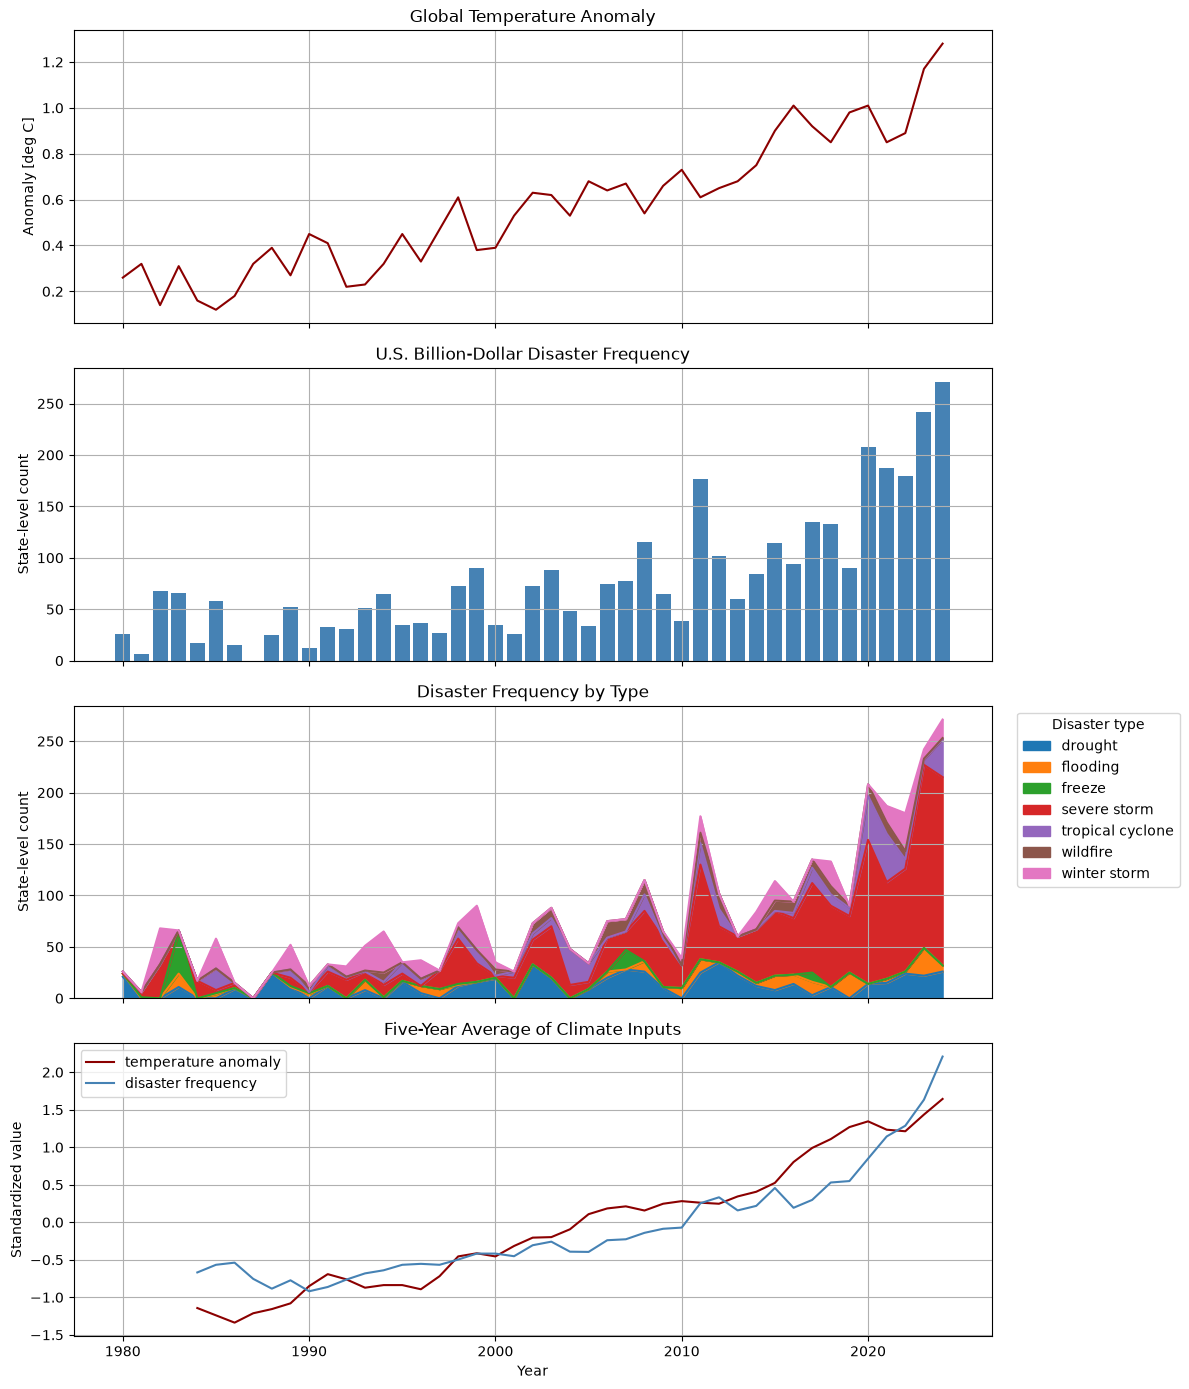

In [21]:
fig, axes = plt.subplots(nrows=4, figsize=(12, 14), sharex=True)

axes[0].plot(climate.index, climate["temperature_anomaly"], color="darkred")
axes[0].set_title("Global Temperature Anomaly")
axes[0].set_ylabel("Anomaly [deg C]")
axes[0].grid(True)

axes[1].bar(climate.index, climate["total_disasters"], color="steelblue")
axes[1].set_title("U.S. Billion-Dollar Disaster Frequency")
axes[1].set_ylabel("State-level count")
axes[1].grid(True)

disaster_by_year.loc[1980:2024, disaster_columns].plot(kind="area", stacked=True, ax=axes[2])
axes[2].set_title("Disaster Frequency by Type")
axes[2].set_ylabel("State-level count")
axes[2].grid(True)
axes[2].legend(title="Disaster type", bbox_to_anchor=(1.02, 1), loc="upper left")

climate[["temperature_z", "disaster_z"]].rolling(5).mean().plot(ax=axes[3], color=["darkred", "steelblue"])
axes[3].set_title("Five-Year Average of Climate Inputs")
axes[3].set_xlabel("Year")
axes[3].set_ylabel("Standardized value")
axes[3].grid(True)
axes[3].legend(["temperature anomaly", "disaster frequency"])

plt.tight_layout()
plt.show()

## Figure 2. Climate-Risk Score Over Time

The gray bars show normal years and orange bars show high-climate-risk years. This figure is kept as the main signal chart.

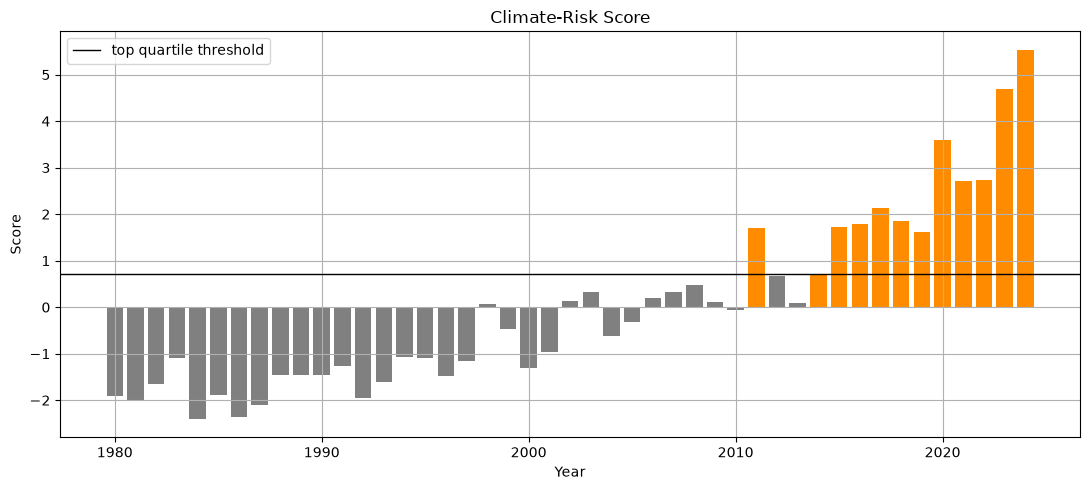

In [22]:
colors = np.where(climate["high_climate_risk"], "darkorange", "gray")
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(climate.index, climate["climate_risk_score"], color=colors)
ax.axhline(risk_threshold, color="black", linewidth=1, label="top quartile threshold")
ax.set_title("Climate-Risk Score")
ax.set_xlabel("Year")
ax.set_ylabel("Score")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Sector ETF Data and Portfolio Rule

The project uses five U.S. sector ETFs:

- XLE: Energy
- XLU: Utilities
- XLI: Industrials
- XLK: Technology
- XLF: Financials

The benchmark is equal-weighted. The climate-risk-aware portfolio uses equal weights in normal years. After a high-climate-risk year, it tilts toward technology and utilities and away from energy and industrials.

In [ ]:
sector_tickers = ["XLE", "XLU", "XLI", "XLK", "XLF"]
prices = yf.download(sector_tickers, start="1998-12-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"]
prices = prices.dropna(how="all")
monthly_prices = prices.resample("ME").last()
monthly_returns_all = monthly_prices.pct_change().dropna()
monthly_returns = monthly_returns_all.loc["2009":]
normal_weights = pd.Series({"XLE": 0.20, "XLU": 0.20, "XLI": 0.20, "XLK": 0.20, "XLF": 0.20})
high_risk_weights = pd.Series({"XLE": 0.05, "XLU": 0.25, "XLI": 0.05, "XLK": 0.55, "XLF": 0.10})
weights = pd.DataFrame({
    "normal years": normal_weights,
    "after high-climate-risk years": high_risk_weights
})
weights

,normal years,after high-climate-risk years
XLE,0.2,0.05
XLU,0.2,0.25
XLI,0.2,0.05
XLK,0.2,0.55
XLF,0.2,0.10


## Figure 3. Portfolio Rule

This figure shows the investment rule directly. The climate-risk-aware portfolio moves more capital into technology and utilities after high-climate-risk years.

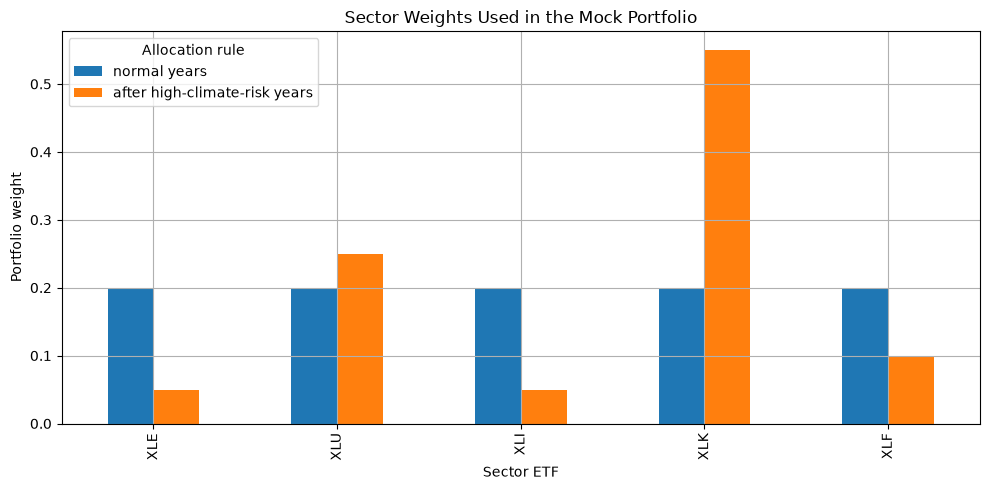

In [24]:
ax = weights.plot(kind="bar", figsize=(10, 5))
ax.set_title("Sector Weights Used in the Mock Portfolio")
ax.set_xlabel("Sector ETF")
ax.set_ylabel("Portfolio weight")
ax.grid(True)
ax.legend(title="Allocation rule")
plt.tight_layout()
plt.show()

## 3. Mock $50 Million Backtest

The backtest starts with $50 million in 2009. Each month, portfolio return is calculated as the weighted average of sector ETF returns. The climate-risk-aware portfolio uses the previous year's signal to decide whether to use normal weights or high-risk weights.

In [25]:
previous_signal = climate["high_climate_risk"].shift(1).fillna(False)
monthly_signal = pd.Series(monthly_returns.index.year.map(previous_signal), index=monthly_returns.index)
initial_capital = 50_000_000

benchmark_returns = monthly_returns.dot(normal_weights)
climate_portfolio_returns = []

for date, row in monthly_returns.iterrows():
    if monthly_signal.loc[date]:
        climate_portfolio_returns.append(row.dot(high_risk_weights))
    else:
        climate_portfolio_returns.append(row.dot(normal_weights))

climate_portfolio_returns = pd.Series(climate_portfolio_returns, index=monthly_returns.index)
portfolio_returns = pd.DataFrame({
    "equal-weight benchmark": benchmark_returns,
    "climate-risk-aware mock portfolio": climate_portfolio_returns
})
wealth = initial_capital * (1 + portfolio_returns).cumprod()
running_peak = wealth.cummax()
drawdown = wealth / running_peak - 1
annual_returns = (1 + portfolio_returns).resample("YE").prod() - 1
annual_returns.index = annual_returns.index.year
annual_return_difference = annual_returns["climate-risk-aware mock portfolio"] - annual_returns["equal-weight benchmark"]

summary = pd.DataFrame({
    "equal-weight benchmark": [
        (1 + portfolio_returns["equal-weight benchmark"]).prod() ** (12 / len(portfolio_returns)) - 1,
        portfolio_returns["equal-weight benchmark"].std() * np.sqrt(12),
        drawdown["equal-weight benchmark"].min(),
        portfolio_returns["equal-weight benchmark"].quantile(0.05),
        wealth["equal-weight benchmark"].iloc[-1],
        0
    ],
    "climate-risk-aware mock portfolio": [
        (1 + portfolio_returns["climate-risk-aware mock portfolio"]).prod() ** (12 / len(portfolio_returns)) - 1,
        portfolio_returns["climate-risk-aware mock portfolio"].std() * np.sqrt(12),
        drawdown["climate-risk-aware mock portfolio"].min(),
        portfolio_returns["climate-risk-aware mock portfolio"].quantile(0.05),
        wealth["climate-risk-aware mock portfolio"].iloc[-1],
        wealth["climate-risk-aware mock portfolio"].iloc[-1] - wealth["equal-weight benchmark"].iloc[-1]
    ]
}, index=[
    "annualized return",
    "annualized volatility",
    "worst drawdown",
    "5th percentile monthly return",
    "ending value",
    "excess ending value vs benchmark"
])
summary

,equal-weight benchmark,climate-risk-aware mock portfolio
annualized return,1.340989e-01,1.575154e-01
annualized volatility,1.619481e-01,1.545759e-01
worst drawdown,-2.774375e-01,-2.116705e-01
5th percentile monthly return,-6.984213e-02,-7.056797e-02
ending value,3.744421e+08,5.192765e+08
excess ending value vs benchmark,0.000000e+00,1.448344e+08


## Figure 4. $50 Million Backtest Result

This figure compares cumulative portfolio value and drawdown. The top panel shows the growth of $50 million, while the bottom panel shows losses from each portfolio's previous peak.

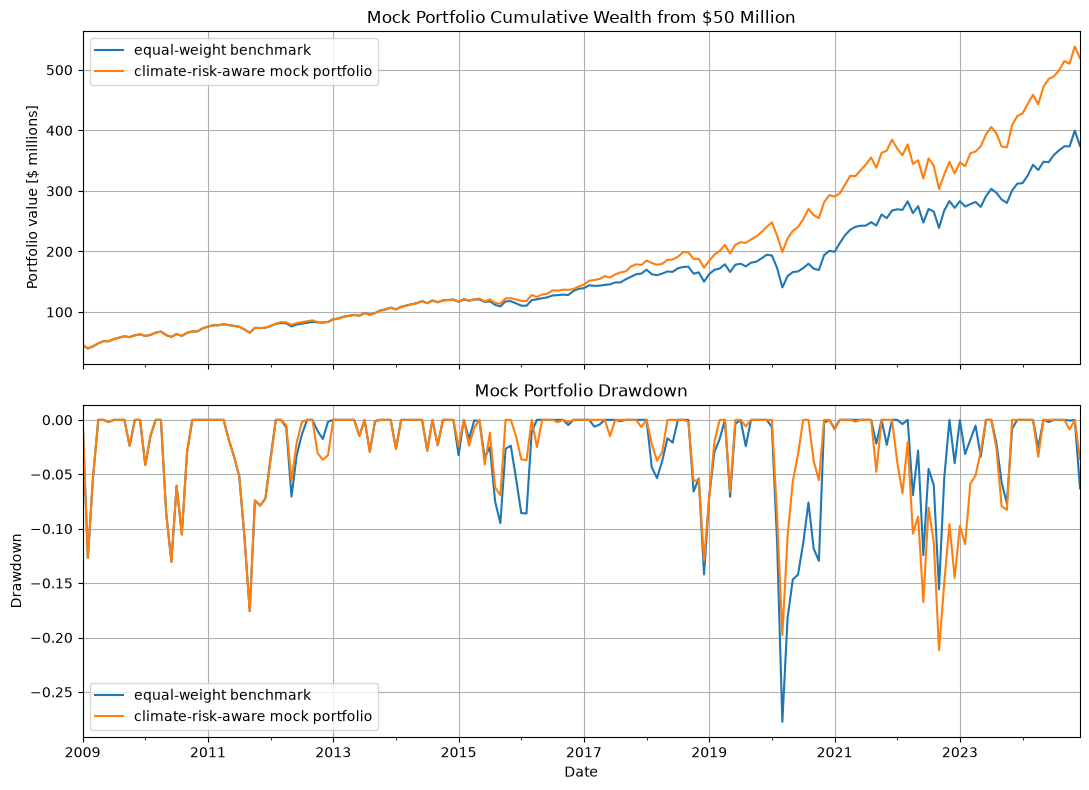

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(11, 8), sharex=True)
(wealth / 1_000_000).plot(ax=axes[0])
axes[0].set_title("Mock Portfolio Cumulative Wealth from $50 Million")
axes[0].set_ylabel("Portfolio value [$ millions]")
axes[0].grid(True)
axes[0].legend()
drawdown.plot(ax=axes[1])
axes[1].set_title("Mock Portfolio Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()

## Figure 5. Annual Return Difference

This figure shows the year-by-year return difference between the equal-weight benchmark and the climate-risk-aware mock portfolio. The bottom panel highlights when the climate-risk-aware portfolio outperformed or underperformed.

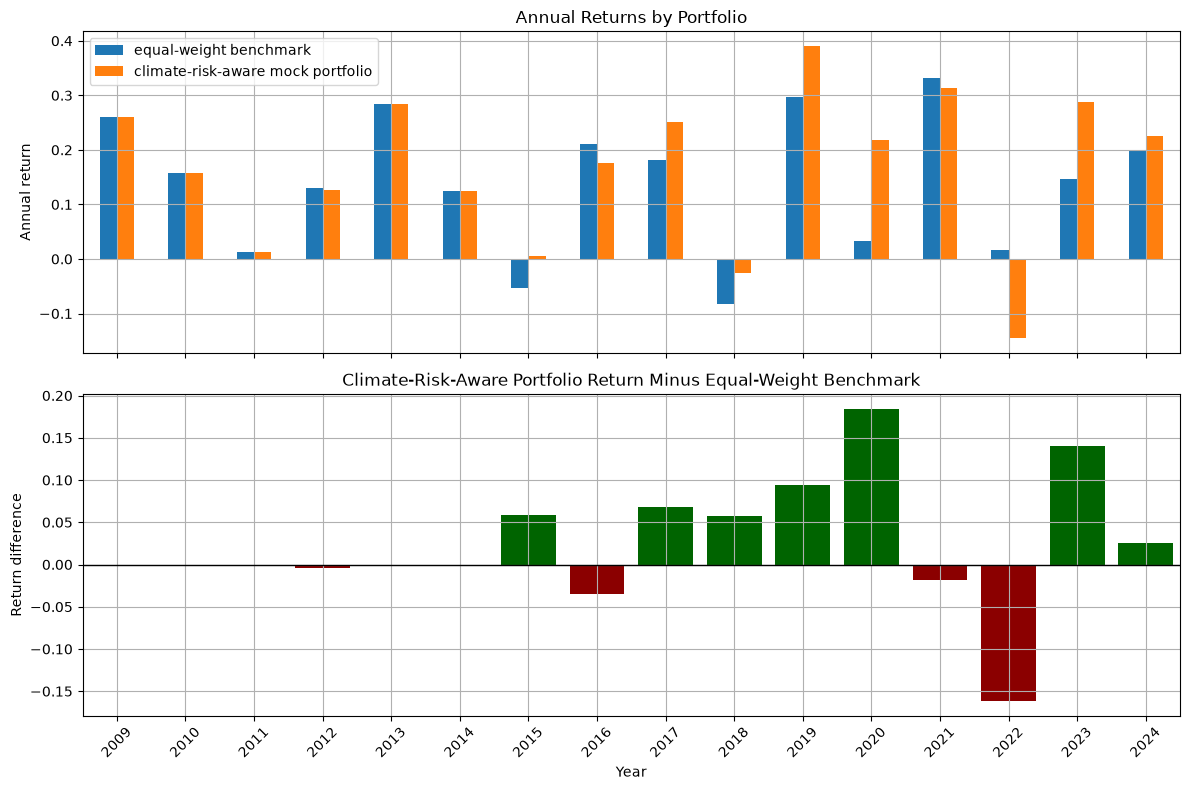

In [ ]:
annual_returns_by_year = annual_returns.copy()
annual_returns_by_year.index = annual_returns_by_year.index.astype(str)
annual_return_difference_by_year = annual_return_difference.copy()
annual_return_difference_by_year.index = annual_return_difference_by_year.index.astype(str)
fig, axes = plt.subplots(nrows=2, figsize=(12, 8), sharex=True)
annual_returns_by_year.plot(kind="bar", ax=axes[0])
axes[0].set_title("Annual Returns by Portfolio")
axes[0].set_ylabel("Annual return")
axes[0].grid(True)
axes[0].legend()
bar_colors = np.where(annual_return_difference_by_year >= 0, "darkgreen", "darkred")
axes[1].bar(annual_return_difference_by_year.index, annual_return_difference_by_year, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Climate-Risk-Aware Portfolio Return Minus Equal-Weight Benchmark")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Return difference")
axes[1].grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Main Findings

The climate-risk score translates public climate and disaster data into an investment signal. The mock portfolio uses that signal to change sector weights after high-climate-risk years. In the historical backtest, the climate-risk-aware mock portfolio grows more than the equal-weight benchmark from the same $50 million starting value.

The annual return difference figure shows that the strategy does not win every year. However, the years when it outperforms are large enough to create a meaningful cumulative performance gap. This is not a real trading recommendation and does not prove causality. It is a transparent backtest showing how Climate VaR-style thinking can be turned into a reproducible portfolio experiment.